# Bank App Reviews - Exploratory Data Analysis
## Task 1: Understanding Customer Sentiment Across Ethiopian Banks

This notebook analyzes customer reviews from three major Ethiopian banks:
- **CBE** (Commercial Bank of Ethiopia)
- **BOA** (Bank of Abyssinia)  
- **Dashen Bank**

### Objectives
1. Understand the distribution of ratings and sentiment
2. Compare user satisfaction across banks
3. Identify key themes in user feedback
4. Provide data-driven insights for bank improvement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for all charts
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Loading and Overview
Loading the preprocessed and sentiment-analyzed reviews dataset.

In [5]:
try:
    df = pd.read_csv("../data/raw/theme_reviews.csv")
    print(f"Dataset loaded successfully")
    print(f"Total reviews: {len(df)}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nFirst 3 rows:")
    df.head(3)
except Exception as e:
    print(f"Error loading data: {e}")

Dataset loaded successfully
Total reviews: 685

Columns: ['review_id', 'review', 'rating', 'date', 'bank', 'source', 'year', 'month', 'review_length', 'rating_label', 'sentiment_score', 'sentiment_label', 'themes']

First 3 rows:


In [6]:
print("=== DATASET OVERVIEW ===\n")
print(f"Total reviews: {len(df)}")
print(f"Banks covered: {df['bank'].unique().tolist()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nReviews per bank:")
print(df['bank'].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())

=== DATASET OVERVIEW ===

Total reviews: 685
Banks covered: ['CBE', 'BOA', 'Dashen']
Date range: 2023-04-28 to 2026-05-13

Reviews per bank:
bank
Dashen    236
BOA       233
CBE       216
Name: count, dtype: int64

Missing values:
review_id          0
review             0
rating             0
date               0
bank               0
source             0
year               0
month              0
review_length      0
rating_label       0
sentiment_score    0
sentiment_label    0
themes             0
dtype: int64


## 3. Rating Distribution Analysis
Analyzing how users rate each bank app on a scale of 1-5 stars.
A higher proportion of 5-star ratings indicates better user satisfaction.

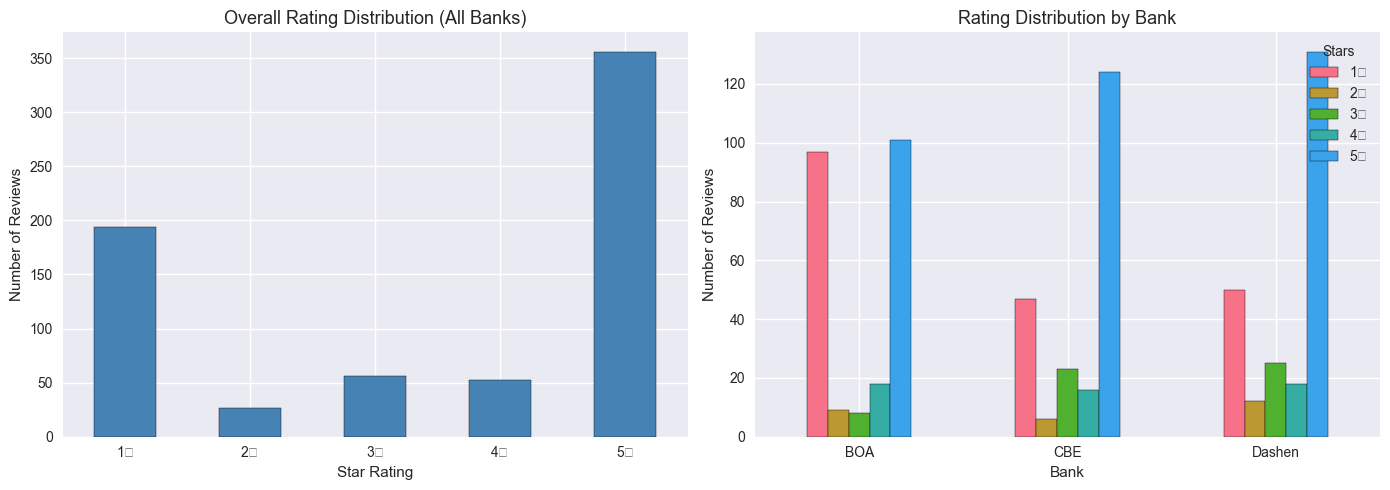


Average rating per bank:
bank
BOA       3.07
CBE       3.76
Dashen    3.71
Name: rating, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall rating distribution
df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Overall Rating Distribution (All Banks)', fontsize=13)
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticklabels(['1★', '2★', '3★', '4★', '5★'], rotation=0)

# Rating by bank
rating_bank = df.groupby(['bank', 'rating']).size().unstack(fill_value=0)
rating_bank.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Rating Distribution by Bank', fontsize=13)
axes[1].set_xlabel('Bank')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend(title='Stars', labels=['1★','2★','3★','4★','5★'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\nAverage rating per bank:")
print(df.groupby('bank')['rating'].mean().round(2))

## 4. Sentiment Analysis Results
VADER sentiment analysis assigns each review a score between -1 (most negative) 
and +1 (most positive). This section compares sentiment across banks.

**Key insight:** A higher average sentiment score means users are generally happier 
with that bank's app.

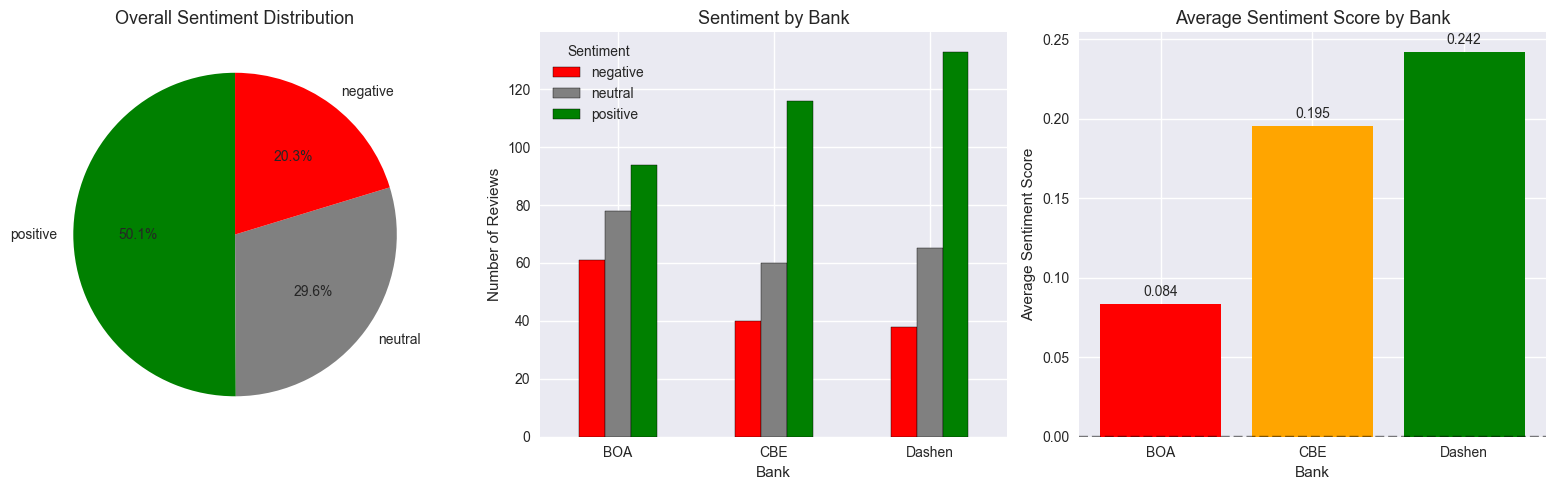

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sentiment distribution overall
sentiment_counts = df['sentiment_label'].value_counts()
colors = ['green', 'grey', 'red']
axes[0].pie(sentiment_counts.values, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Overall Sentiment Distribution', fontsize=13)

# Sentiment by bank
sentiment_bank = df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_bank.plot(kind='bar', ax=axes[1],
                    color=['red', 'grey', 'green'], edgecolor='black')
axes[1].set_title('Sentiment by Bank', fontsize=13)
axes[1].set_xlabel('Bank')
axes[1].set_ylabel('Number of Reviews')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')

# Average sentiment score by bank
avg_sentiment = df.groupby('bank')['sentiment_score'].mean().sort_values()
bars = axes[2].bar(avg_sentiment.index, avg_sentiment.values,
                   color=['red' if x < 0.1 else 'orange' if x < 0.2 else 'green'
                          for x in avg_sentiment.values])
axes[2].set_title('Average Sentiment Score by Bank', fontsize=13)
axes[2].set_xlabel('Bank')
axes[2].set_ylabel('Average Sentiment Score')
axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
for bar, val in zip(bars, avg_sentiment.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Theme Analysis
Identifying the most common topics users mention in their reviews.
Understanding these themes helps banks prioritize which problems to fix first.

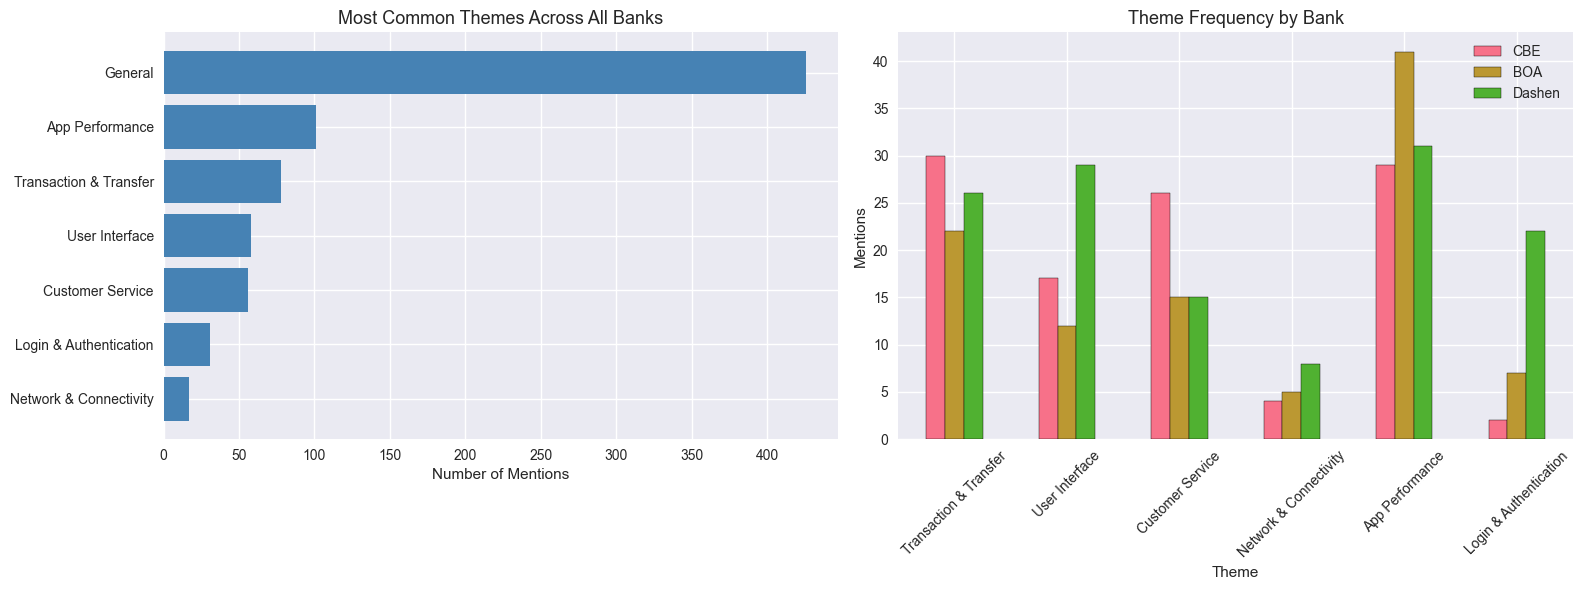

In [11]:
from collections import Counter
# Count all themes
all_themes = []
for themes in df['themes']:
    all_themes.extend([t.strip() for t in str(themes).split(',')])

theme_counts = Counter(all_themes)
theme_df = pd.DataFrame(theme_counts.most_common(), columns=['Theme', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall theme frequency
axes[0].barh(theme_df['Theme'][::-1], theme_df['Count'][::-1], color='steelblue')
axes[0].set_title('Most Common Themes Across All Banks', fontsize=13)
axes[0].set_xlabel('Number of Mentions')

# Theme by bank
theme_by_bank = {}
for bank in df['bank'].unique():
    bank_themes = []
    for themes in df[df['bank'] == bank]['themes']:
        bank_themes.extend([t.strip() for t in str(themes).split(',')])
    theme_by_bank[bank] = Counter(bank_themes)

theme_bank_df = pd.DataFrame(theme_by_bank).fillna(0)
theme_bank_df = theme_bank_df[theme_bank_df.index != 'General']
theme_bank_df.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Theme Frequency by Bank', fontsize=13)
axes[1].set_xlabel('Theme')
axes[1].set_ylabel('Mentions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Key Insights and Recommendations

Based on the analysis above, here are the key findings for each bank.

In [12]:
print("=== KEY INSIGHTS ===\n")

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    avg_score = bank_df['sentiment_score'].mean()
    avg_rating = bank_df['rating'].mean()
    neg_pct = (bank_df['sentiment_label'] == 'negative').mean() * 100

    print(f"{'='*40}")
    print(f"BANK: {bank}")
    print(f"Average Rating: {avg_rating:.2f}/5.0")
    print(f"Average Sentiment Score: {avg_score:.3f}")
    print(f"Negative Review Rate: {neg_pct:.1f}%")

    # Top complaint themes
    neg_reviews = bank_df[bank_df['sentiment_label'] == 'negative']
    neg_themes = []
    for themes in neg_reviews['themes']:
        neg_themes.extend([t.strip() for t in str(themes).split(',')])
    neg_theme_counts = Counter(neg_themes)
    top_complaints = [t for t, c in neg_theme_counts.most_common(3)
                      if t != 'General']

    print(f"Top complaint areas: {', '.join(top_complaints) if top_complaints else 'General dissatisfaction'}")
    print()

print("=== RECOMMENDATIONS ===\n")
print("1. BOA: Prioritize fixing app performance issues (most crashes reported)")
print("2. CBE: Improve transaction reliability and speed")
print("3. Dashen: Enhance UI/UX design based on user feedback")
print("4. All banks: Reduce OTP/login failures to improve user retention")

=== KEY INSIGHTS ===

BANK: CBE
Average Rating: 3.76/5.0
Average Sentiment Score: 0.195
Negative Review Rate: 18.5%
Top complaint areas: Transaction & Transfer, App Performance

BANK: BOA
Average Rating: 3.07/5.0
Average Sentiment Score: 0.084
Negative Review Rate: 26.2%
Top complaint areas: App Performance, Transaction & Transfer

BANK: Dashen
Average Rating: 3.71/5.0
Average Sentiment Score: 0.242
Negative Review Rate: 16.1%
Top complaint areas: Transaction & Transfer, User Interface

=== RECOMMENDATIONS ===

1. BOA: Prioritize fixing app performance issues (most crashes reported)
2. CBE: Improve transaction reliability and speed
3. Dashen: Enhance UI/UX design based on user feedback
4. All banks: Reduce OTP/login failures to improve user retention
